This is a Jupyter Notebook Script that will get data from pre-downloaded ISIMIP .nc files and find extract the locations where wind farms are currently located globally. For more information, reach out to Bryn Stecher (bs3157@barnard.edu)

In [25]:
%%time
import pandas as pd
import netCDF4 as nc
import dask.dataframe as dd 
import matplotlib as plt
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from pathlib import Path
import time
import hvplot as hv  
import hvplot.xarray  
import hvplot.xarray  # noqa
import rioxarray
import geopandas
from shapely.geometry import mapping


CPU times: total: 0 ns
Wall time: 0 ns


### Import Global Energy Model data, this contains all the locations of wind farms globally

Announced: Proposed projects that have been described in corporate or government plans or media releases but have not yet taken concrete steps such as applying for permits.

Pre-construction: Projects that are actively moving forward in seeking governmental approvals, land rights, or financing.

Construction: Site preparation and equipment installation are underway.

Operating: The project has been formally commissioned; commercial operation has begun.

In [26]:
USA_Shape = geopandas.read_file('States_shapefile.shp', crs="epsg:4326")

In [40]:
ds = xr.open_mfdataset('gfdl-esm4_r1i1p1f1_w5e5_ssp370_sfcwind_global_daily_2015_2020.nc', parallel=True) # INPUT .NC FILE  NAME HERE
ds.rio.write_crs("epsg:4326", inplace=True)

<xarray.Dataset>
Dimensions:      (lon: 720, lat: 360, time: 2192)
Coordinates:
  * lon          (lon) float64 -179.8 -179.2 -178.8 -178.2 ... 178.8 179.2 179.8
  * lat          (lat) float64 89.75 89.25 88.75 88.25 ... -88.75 -89.25 -89.75
  * time         (time) datetime64[ns] 2015-01-01 2015-01-02 ... 2020-12-31
    spatial_ref  int32 0
Data variables:
    sfcwind      (time, lat, lon) float32 dask.array<chunksize=(2192, 360, 720), meta=np.ndarray>
Attributes:
    institution:  Potsdam Institute for Climate Impact Research (PIK)
    contact:      ISIMIP cross-sectoral science team <info@isimip.org> <https...
    references:   Lange (2019) <https://doi.org/10.5194/gmd-12-3055-2019> and...
    title:        ISIMIP3b bias-adjusted climate input data
    project:      Inter-Sectoral Impact Model Intercomparison Project phase 3...
    summary:      CMIP6 daily output data bias-adjusted and statistically dow...

In [41]:
ds

<xarray.Dataset>
Dimensions:      (lon: 720, lat: 360, time: 2192)
Coordinates:
  * lon          (lon) float64 -179.8 -179.2 -178.8 -178.2 ... 178.8 179.2 179.8
  * lat          (lat) float64 89.75 89.25 88.75 88.25 ... -88.75 -89.25 -89.75
  * time         (time) datetime64[ns] 2015-01-01 2015-01-02 ... 2020-12-31
    spatial_ref  int32 0
Data variables:
    sfcwind      (time, lat, lon) float32 dask.array<chunksize=(2192, 360, 720), meta=np.ndarray>
Attributes:
    institution:  Potsdam Institute for Climate Impact Research (PIK)
    contact:      ISIMIP cross-sectoral science team <info@isimip.org> <https...
    references:   Lange (2019) <https://doi.org/10.5194/gmd-12-3055-2019> and...
    title:        ISIMIP3b bias-adjusted climate input data
    project:      Inter-Sectoral Impact Model Intercomparison Project phase 3...
    summary:      CMIP6 daily output data bias-adjusted and statistically dow...

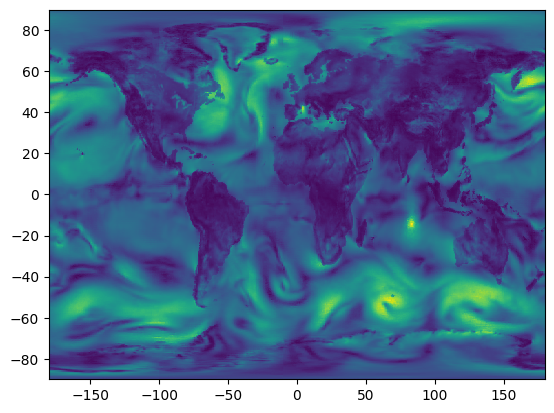

In [42]:
# plot the first timestep
lat = ds.sfcwind.lat.data  # numpy array
lon = ds.sfcwind.lon.data  # numpy array
sfcwind = ds.sfcwind.data  # numpy array
plt.figure()
plt.pcolormesh(lon, lat, sfcwind[0, :, :])

In [43]:
clipped = ds.rio.clip(USA_Shape.geometry.apply(mapping), USA_Shape.crs, drop=False)

In [44]:
clipped

<xarray.Dataset>
Dimensions:      (lon: 720, lat: 360, time: 2192)
Coordinates:
  * lon          (lon) float64 -179.8 -179.2 -178.8 -178.2 ... 178.8 179.2 179.8
  * lat          (lat) float64 89.75 89.25 88.75 88.25 ... -88.75 -89.25 -89.75
  * time         (time) datetime64[ns] 2015-01-01 2015-01-02 ... 2020-12-31
    spatial_ref  int32 0
Data variables:
    sfcwind      (time, lat, lon) float32 dask.array<chunksize=(2192, 360, 720), meta=np.ndarray>
Attributes:
    institution:  Potsdam Institute for Climate Impact Research (PIK)
    contact:      ISIMIP cross-sectoral science team <info@isimip.org> <https...
    references:   Lange (2019) <https://doi.org/10.5194/gmd-12-3055-2019> and...
    title:        ISIMIP3b bias-adjusted climate input data
    project:      Inter-Sectoral Impact Model Intercomparison Project phase 3...
    summary:      CMIP6 daily output data bias-adjusted and statistically dow...

In [45]:
dask = clipped[['lat', "lon", "sfcwind", "time"]].to_dask_dataframe()

In [46]:
dask

,lat,lon,time,spatial_ref,sfcwind
npartitions=1,,,,,
0,float64,float64,datetime64[ns],int32,float32
568166399,...,...,...,...,...


### Add Other Variables
These include capacity factors, wind speed at 80m, floor wind speed at 80m, and IEC Classification

In [47]:
# Adds the wind speeds for 80m 
dask['sfc_wind80m'] = dask['sfcwind']*((80/10)**0.143) 
# Adds the floor wind speeds for 80m 
dask['sfc_wind80m_floor'] = np.floor((dask['sfc_wind80m']) * 2) / 2
dask.sfc_wind80m = dask.sfc_wind80m.astype(float)
# merged_df.drop(['file', 'text', 'lat', 'lon'], axis=1, inplace=True) # Clean up data table

In [48]:
dask

,lat,lon,time,spatial_ref,sfcwind,sfc_wind80m,sfc_wind80m_floor
npartitions=1,,,,,,,
0,float64,float64,datetime64[ns],int32,float32,float64,float32
568166399,...,...,...,...,...,...,...


In [49]:
dask.to_csv("ssp370_entire_usa_onshore_daily_2015_2020.csv", index=False, single_file=True)